# Churn prediction: research notebook (archived)

This notebook is the original exploration and tuning work. The maintained, tested pipeline now lives in `src/churn_prediction/` (see the README):

| Notebook cells | Package module |
|---|---|
| preprocessing & feature engineering | `churn_prediction.preprocessing`, `churn_prediction.features`, `python -m churn_prediction.build_features` |
| Optuna search & ensemble search | `python -m churn_prediction.tune` |
| final training & submissions | `python -m churn_prediction.train`, `python -m churn_prediction.predict` |
| threshold / importance analysis | `python -m churn_prediction.evaluate` and the Streamlit app |

Data paths have been updated to the new layout (run from the `notebooks/` folder). The tuned parameters are now stored as JSON in `models/params/` instead of the `Parameters/*.pkl` files used by the save/load cells below.

Known issues kept for the record: the ensemble search cell leaves the logistic-regression probabilities out of the blend it scores, and the "ensemble" submission cell thresholds the XGBoost probabilities instead of the ensemble ones.

In [ ]:
# df_user = df_train.groupby('userId').agg(
#     churn_flag=('churn_flag', 'max'),
#     pages=('page', lambda x: list(x))
# )

# all_pages = ['NextSong', 'Downgrade', 'Help', 'Home', 'Thumbs Up', 
#              'Add Friend', 'Thumbs Down', 'Add to Playlist', 'Logout',
#              'About', 'Settings', 'Save Settings', 'Cancel', 
#              'Cancellation Confirmation', 'Submit Downgrade', 'Roll Advert',
#              'Upgrade', 'Error', 'Submit Upgrade']

# for p in all_pages:
#     df_user[p] = df_user['pages'].apply(lambda x: int(p in x))

# X = df_user[all_pages]
# y = df_user['churn_flag']

# clf = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000)
# clf.fit(X, y)

# coef_table = pd.DataFrame({
#     'page': X.columns,
#     'coef': clf.coef_[0],
#     'odds_ratio': np.exp(clf.coef_[0])
# }).sort_values('odds_ratio', ascending=False)

# print(coef_table)

# from scipy.stats import chi2_contingency


# Chi^2 test for checking feature significance (here status, but used previously for others)
# contingency = pd.crosstab(df_train['status'], df_train['churn_flag'])

# # run chi-square test
# chi2, p, dof, expected = chi2_contingency(contingency)

# print("Chi-square statistic:", chi2)
# print("Degrees of freedom:", dof)
# print("p-value:", p)



In [7]:
# # Basic and Naive EDA
# num_cols = df_train.select_dtypes(include=["int64", "float64"]).columns

# # Histograms
# for col in num_cols:
#     plt.figure()
#     df_train[col].hist()
#     plt.title(f"Histogram of {col}")
#     plt.xlabel(col)
#     plt.ylabel("Frequency")
#     plt.show()

# # Box plots
# for col in num_cols:
#     plt.figure()
#     df_train.boxplot(column=col)
#     plt.title(f"Box plot of {col}")
#     plt.ylabel(col)
#     plt.show()

For Model: logistic_regression
For Training Set:
Macro F1 Score: 0.4758123219503342
Confusion Matrix:


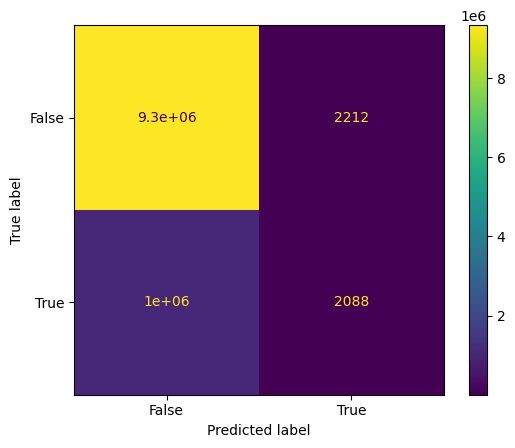

For Validation Set:
Macro F1 Score: 0.47243264483248404
Confusion Matrix:


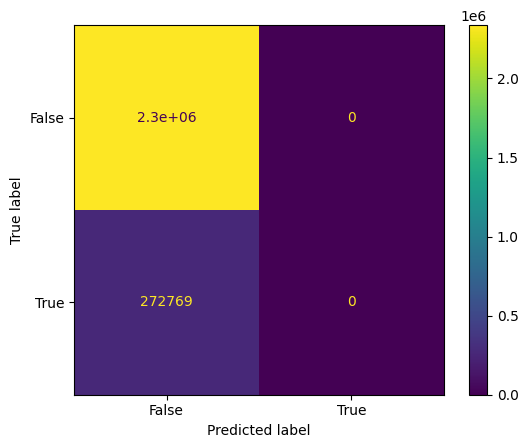

For Model: decision_tree
For Training Set:
Macro F1 Score: 0.5332423619088209
Confusion Matrix:


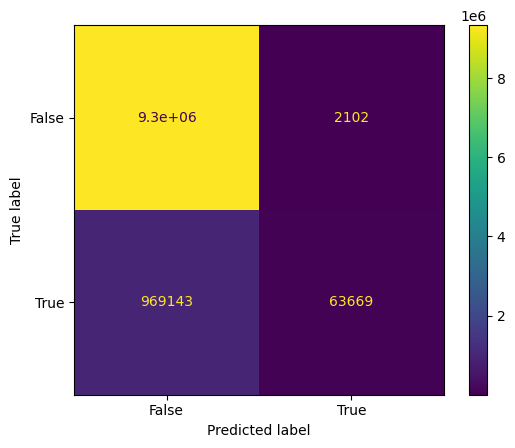

For Validation Set:
Macro F1 Score: 0.53008083491724
Confusion Matrix:


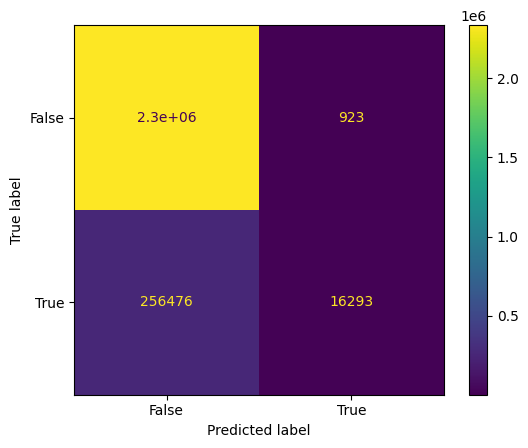

For Model: Random_forest
For Training Set:
Macro F1 Score: 0.5295027223542345
Confusion Matrix:


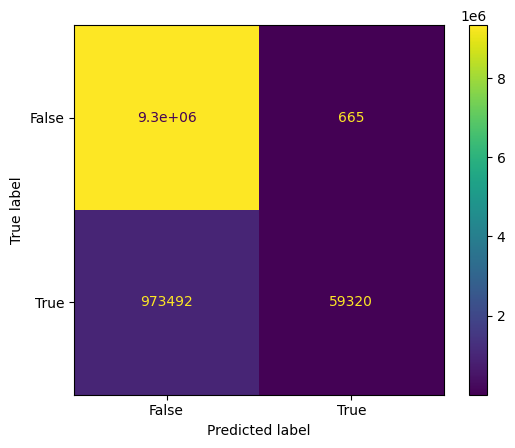

For Validation Set:
Macro F1 Score: 0.5287995986834758
Confusion Matrix:


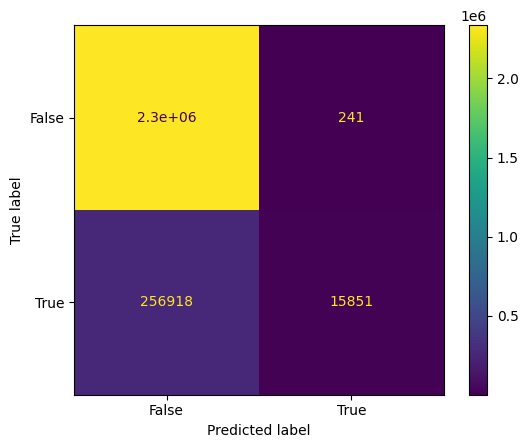

For Model: GBDT


KeyboardInterrupt: 

In [ ]:
# Old code for basic Confusion matrix and model evaluation for a first model selection
# Obsolete after model comparison refactor
train_scores = []
test_scores = []
recall_test_scores = []

models = {
    "logistic_regression": LogisticRegression(random_state=42, max_iter=10000),
    "decision_tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random_forest": RandomForestClassifier(
        n_estimators=150, max_depth=4, random_state=42
    ),
    "GBDT": GradientBoostingClassifier(n_estimators=150, max_depth=4, random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=200, max_depth=5, random_state=42),
    "ridge_regression": RidgeClassifier(random_state=42),
    "knn": KNeighborsClassifier(n_neighbors=5),
}

model_names = models.keys()

for model in model_names:
    print("For Model:", model)

    models[model].fit(X_train, y_train)

    print("For Training Set:")

    y_train_pred = models[model].predict(X_train)

    f1_train = f1_score(y_train, y_train_pred, average="macro")
    print("Macro F1 Score:", f1_train)

    print("Confusion Matrix:")
    conf_matrix = confusion_matrix(y_train, y_train_pred)
    cm_display = ConfusionMatrixDisplay(
        confusion_matrix=conf_matrix, display_labels=[False, True]
    )
    cm_display.plot()
    plt.show()

    print("For Validation Set:")

    y_test_pred = models[model].predict(X_val)

    f1_test = f1_score(y_val, y_test_pred, average="macro")
    print("Macro F1 Score:", f1_test)

    recall_test_score = recall_score(y_val, y_test_pred, average="macro")

    print("Confusion Matrix:")
    conf_matrix = confusion_matrix(y_val, y_test_pred)
    cm_display = ConfusionMatrixDisplay(
        confusion_matrix=conf_matrix, display_labels=[False, True]
    )
    cm_display.plot()
    plt.show()

    train_scores.append(f1_train)
    test_scores.append(f1_test)
    recall_test_scores.append(recall_test_score)



In [74]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score, recall_score, precision_score
from sklearn.pipeline import make_pipeline

import optuna
from optuna.samplers import TPESampler
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
CHURN_PAGES = {
    'Cancel': 7, 'Cancellation Confirmation': 7, 'Downgrade': 0.16,
    'Submit Upgrade': 0.14, 'Upgrade': 0.03, 'Settings': 0.02, 'Submit Downgrade': 0.01
}

RETAIN_PAGES = {
    'Save Settings': -0.0007, 'Thumbs Down': -0.016, 'About': -0.054, 'Help': -0.058,
    'Add Friend': -0.158, 'Add to Playlist': -0.383, 'Roll Advert': -0.422,
    'Thumbs Up': -0.716, 'Home': -1.423, 'NextSong': -1.925
}

KEY_PAGES = ['NextSong', 'Thumbs Up', 'Thumbs Down', 'Add to Playlist',
             'Home', 'Settings', 'Downgrade', 'Upgrade', 'Roll Advert']


def compute_cumulative_risk(user_df):
    churn_score = 0
    not_churn_score = 0
    churn_list = []
    not_churn_list = []
    
    for page in user_df['page']:
        churn_score += CHURN_PAGES.get(page, 0)
        not_churn_score += RETAIN_PAGES.get(page, 0)
        churn_list.append(churn_score)
        not_churn_list.append(not_churn_score)
    
    user_df['churn_risk_score'] = churn_list
    user_df['not_churn_score'] = not_churn_list
    return user_df


def forward_looking_churn(df, prediction_window_days=10, buffer_days=0):
    df = df.sort_values(['userId', 'ts']).reset_index(drop=True)
    
    churn_events = df[df['churn_flag'] == 1].groupby('userId')['ts'].min().reset_index()
    churn_events.columns = ['userId', 'churn_time']
    df = df.merge(churn_events, on='userId', how='left')
    
    df['days_until_churn'] = (df['churn_time'] - df['ts']).dt.total_seconds() / 86400
    df['will_churn_in_10d'] = ((df['days_until_churn'] >= 0) & 
                                (df['days_until_churn'] <= prediction_window_days)).astype(int)
    df['will_churn_in_10d'] = df['will_churn_in_10d'].fillna(0).astype(int)
    
    if buffer_days > 0:
        mask_keep = (df['days_until_churn'].isna()) | (df['days_until_churn'] > buffer_days)
    else:
        mask_keep = (df['days_until_churn'].isna()) | (df['days_until_churn'] > 0)
    df_clean = df[mask_keep].copy()
    
    def filter_non_churner_tail(user_df):
        if user_df['churn_time'].isna().all():
            max_time = user_df['ts'].max()
            cutoff = max_time - pd.Timedelta(days=prediction_window_days)
            return user_df[user_df['ts'] <= cutoff]
        return user_df
    
    df_clean = df_clean.groupby('userId', group_keys=False).apply(filter_non_churner_tail)
    df_clean = df_clean.drop(columns=['churn_time', 'days_until_churn', 'churn_flag'])
    return df_clean.reset_index(drop=True)


def preprocess_data(df, is_train=True):
    df['churn_flag'] = ((df['auth'] == 'Cancelled') | 
                        (df['page'] == 'Cancellation Confirmation')).astype(int)
    
    df['ts'] = pd.to_datetime(df['ts'], unit='ms')
    df = df.sort_values(['userId', 'ts']).reset_index(drop=True)
    
    df['churn_risk_score'] = 0.0
    df['not_churn_score'] = 0.0
    
    df['level'] = df['level'].map({'free': 0, 'paid': 1})
    
    df['timeInSession'] = df.groupby('userId')['ts'].transform(
        lambda x: (x - x.min()).dt.total_seconds()
    )
    df['timeSinceRegistered'] = (df['ts'] - df['registration']).dt.total_seconds()
    
    df = df.groupby('userId', group_keys=False).apply(compute_cumulative_risk)
    
    if is_train:
        df = forward_looking_churn(df, prediction_window_days=10, buffer_days=1)
    
    return df


def create_session_features(df):
    session_stats = df.groupby(['userId', 'sessionId']).agg({
        'itemInSession': 'max',
        'churn_risk_score': 'last',
        'not_churn_score': 'last',
        'ts': ['min', 'max']
    }).reset_index()
    
    session_stats.columns = ['userId', 'sessionId', 'session_length', 'session_churn_risk',
                              'session_retain_score', 'session_start', 'session_end']
    
    session_stats['session_duration'] = (
        (session_stats['session_end'] - session_stats['session_start']).dt.total_seconds() / 60
    )
    
    # User-level aggregation from sessions
    user_session_features = session_stats.groupby('userId').agg({
        'session_length': ['mean', 'std', 'max', 'min'],
        'session_duration': ['mean', 'std', 'max', 'min'],
        'session_churn_risk': ['mean', 'std', 'max', 'last'],
        'session_retain_score': ['mean', 'std', 'min', 'last'],
        'sessionId': 'count'
    }).reset_index()
    
    user_session_features.columns = ['userId'] + [
        '_'.join(col).strip('_') for col in user_session_features.columns.values[1:]
    ]
    
    # Session frequency
    session_gaps = session_stats.groupby('userId')['session_start'].apply(
        lambda x: x.diff().dt.total_seconds() / 3600
    ).reset_index()
    session_gap_stats = session_gaps.groupby('userId')['session_start'].agg(
        ['mean', 'std']
    ).reset_index()
    session_gap_stats.columns = ['userId', 'avg_session_gap_hours', 'std_session_gap_hours']
    
    user_session_features = user_session_features.merge(session_gap_stats, on='userId', how='left')
    
    # Last 3 sessions features (most predictive)
    last_sessions = session_stats.sort_values(['userId', 'session_start']).groupby('userId').tail(3)
    last_session_agg = last_sessions.groupby('userId').agg({
        'session_length': 'mean',
        'session_duration': 'mean',
        'session_churn_risk': 'mean'
    }).reset_index()
    last_session_agg.columns = ['userId', 'last3_avg_length', 'last3_avg_duration', 'last3_avg_risk']
    
    user_session_features = user_session_features.merge(last_session_agg, on='userId', how='left')
    
    return user_session_features


def create_page_features(df):
    page_counts = df.groupby(['userId', 'page']).size().unstack(fill_value=0).reset_index()
    
    for page in KEY_PAGES:
        if page not in page_counts.columns:
            page_counts[page] = 0
    
    page_features = page_counts[['userId'] + [p for p in KEY_PAGES if p in page_counts.columns]]
    
    page_features.columns = ['userId'] + [
        f'page_{col.lower().replace(" ", "_")}' for col in page_features.columns[1:]
    ]
    
    total_events = df.groupby('userId').size().reset_index(name='total_events')
    page_features = page_features.merge(total_events, on='userId')
    
    for col in page_features.columns:
        if col.startswith('page_'):
            page_features[f'{col}_ratio'] = page_features[col] / (page_features['total_events'] + 1)
    
    return page_features


def create_derived_features(full_features):
    full_features['risk_per_session'] = (
        full_features['churn_risk_score'] / (full_features['sessionId_count'] + 1)
    )
    full_features['engagement_decline'] = (
        full_features['session_length_mean'] - full_features['last3_avg_length']
    )
    full_features['session_instability'] = (
        full_features['session_length_std'] / (full_features['session_length_mean'] + 1)
    )
    return full_features


def make_features(df, is_train=True):
    session_features = create_session_features(df)
    page_features = create_page_features(df)
    
    agg_dict = {
        'level': 'last',
        'churn_risk_score': 'max',
        'not_churn_score': 'min',
        'timeSinceRegistered': 'max'
    }
    
    if is_train:
        agg_dict['will_churn_in_10d'] = 'max'
    
    basic_agg = df.groupby('userId').agg(agg_dict).reset_index()
    
    full_features = basic_agg.merge(session_features, on='userId').merge(page_features, on='userId')
    
    full_features = create_derived_features(full_features)
    
    return full_features

In [ ]:
df_train = pd.read_parquet('../data/raw/train.parquet')
df_test = pd.read_parquet('../data/raw/test.parquet')

# Basic Preprocessing
df_train = preprocess_data(df_train, is_train=True)
df_test = preprocess_data(df_test, is_train=False)

In [ ]:
# Feature Engineering
train_full = make_features(df_train, is_train=True)
test_full = make_features(df_test, is_train=False)

# Save time
train_full.to_parquet('../data/processed/train_features.parquet')
test_full.to_parquet('../data/processed/test_features.parquet')

In [ ]:
# If not loaded
# train_full = pd.read_parquet('../data/processed/train_features.parquet')
# test_full = pd.read_parquet('../data/processed/test_features.parquet')

In [ ]:
target_col = 'will_churn_in_10d' 
X_user = train_full.drop(['userId', target_col], axis=1)
y_user = train_full[target_col]

X_user = X_user.fillna(0)
print(f"Total features: {X_user.shape[1]}, Churn rate: {y_user.mean():.2%}") # print feature count and churn rate 

X_train, X_val, y_train, y_val = train_test_split(X_user, y_user, test_size=0.2, random_state=42, stratify=y_user) # train val split 

scaler = StandardScaler() # standard scaling
X_train_scaled = scaler.fit_transform(X_train) # fit on train
X_val_scaled = scaler.transform(X_val) # transform val

scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1]) # class weight

Total features: 48, Churn rate: 20.49%


In [75]:
# Optuna functions and metric

def combined_score(y_true, y_pred_proba):
    """Combine F1 (macro) and ROC-AUC with weighted average"""
    # Get predictions at default threshold for F1
    y_pred = (y_pred_proba >= 0.5).astype(int)
    f1 = f1_score(y_true, y_pred, average='macro')
    auc = roc_auc_score(y_true, y_pred_proba)
    return 0.6 * f1 + 0.4 * auc

def objective_xgb(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.03, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 700, 1500, step=100),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', scale_pos_weight, scale_pos_weight*1.5),
        'subsample': trial.suggest_float('subsample', 0.6, 0.8),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 3),
        'random_state': 42,
        'eval_metric': 'logloss'
    }
    
    model = xgb.XGBClassifier(**params)
    
    f1_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1_macro', n_jobs=-1)
    auc_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    
    combined = 0.6 * f1_scores.mean() + 0.4 * auc_scores.mean()
    
    trial.set_user_attr('f1_mean', f1_scores.mean())
    trial.set_user_attr('auc_mean', auc_scores.mean())
    
    return combined

def objective_lgb(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.03, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 700, 1500, step=100),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', scale_pos_weight, scale_pos_weight*1.5),
        'num_leaves': trial.suggest_int('num_leaves', 31, 127),
        'random_state': 42,
        'verbose': -1
    }
    
    model = lgb.LGBMClassifier(**params)
    
    f1_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1_macro', n_jobs=-1)
    auc_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    
    combined = 0.6 * f1_scores.mean() + 0.4 * auc_scores.mean()
    
    trial.set_user_attr('f1_mean', f1_scores.mean())
    trial.set_user_attr('auc_mean', auc_scores.mean())
    
    return combined

def objective_cat(trial):
    params = {
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.03, log=True),
        'iterations': trial.suggest_int('iterations', 700, 1500, step=100),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', scale_pos_weight, scale_pos_weight*1.5),
        'random_state': 42,
        'verbose': 0
    }
    
    model = CatBoostClassifier(**params)
    
    f1_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1_macro', n_jobs=-1)
    auc_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    
    combined = 0.6 * f1_scores.mean() + 0.4 * auc_scores.mean()
    
    trial.set_user_attr('f1_mean', f1_scores.mean())
    trial.set_user_attr('auc_mean', auc_scores.mean())
    
    return combined


def objective_logreg(trial):
    penalty = trial.suggest_categorical("penalty", ["l2", "l1"])
    solver = "liblinear" if penalty == "l1" else "lbfgs"
    
    params = {
        "penalty": penalty,
        "C": trial.suggest_float("C", 1e-3, 10.0, log=True),
        "solver": solver,
        "max_iter": trial.suggest_int("max_iter", 100, 800),
        "class_weight": "balanced",
        "n_jobs": -1 if solver == "lbfgs" else None,
        "random_state": 42
    }

    model = LogisticRegression(**params)

    f1_scores = cross_val_score(
        model, X_train_scaled, y_train, cv=5, scoring="f1_macro", n_jobs=-1
    )
    auc_scores = cross_val_score(
        model, X_train_scaled, y_train, cv=5, scoring="roc_auc", n_jobs=-1
    )

    combined = 0.6 * f1_scores.mean() + 0.4 * auc_scores.mean()

    trial.set_user_attr("f1_mean", f1_scores.mean())
    trial.set_user_attr("auc_mean", auc_scores.mean())

    return combined



In [ ]:
print("\n=== Starting Multi-Metric Optuna Optimization (F1 + ROC-AUC) ===\n")

print("Optimizing XGBoost...")
study_xgb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)

best_xgb_params = study_xgb.best_params
best_xgb_model = xgb.XGBClassifier(**best_xgb_params, random_state=42, eval_metric='logloss')
best_xgb_model.fit(X_train_scaled, y_train)

xgb_val_proba = best_xgb_model.predict_proba(X_val_scaled)[:, 1]
xgb_f1 = f1_score(y_val, (xgb_val_proba >= 0.5).astype(int), average='macro')
xgb_auc = roc_auc_score(y_val, xgb_val_proba)

print(f"XGBoost: Combined={study_xgb.best_value:.4f}")
print(f"  CV F1={study_xgb.best_trial.user_attrs['f1_mean']:.4f}, CV AUC={study_xgb.best_trial.user_attrs['auc_mean']:.4f}")
print(f"  Val F1={xgb_f1:.4f}, Val AUC={xgb_auc:.4f}")
print(f"  Best params: {best_xgb_params}\n")

# Optimize LightGBM
print("Optimizing LightGBM...")
study_lgb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_lgb.optimize(objective_lgb, n_trials=50, show_progress_bar=True)

best_lgb_params = study_lgb.best_params
best_lgb_model = lgb.LGBMClassifier(**best_lgb_params, random_state=42, verbose=-1)
best_lgb_model.fit(X_train_scaled, y_train)

lgb_val_proba = best_lgb_model.predict_proba(X_val_scaled)[:, 1]
lgb_f1 = f1_score(y_val, (lgb_val_proba >= 0.5).astype(int), average='macro')
lgb_auc = roc_auc_score(y_val, lgb_val_proba)

print(f"LightGBM: Combined={study_lgb.best_value:.4f}")
print(f"  CV F1={study_lgb.best_trial.user_attrs['f1_mean']:.4f}, CV AUC={study_lgb.best_trial.user_attrs['auc_mean']:.4f}")
print(f"  Val F1={lgb_f1:.4f}, Val AUC={lgb_auc:.4f}")
print(f"  Best params: {best_lgb_params}\n")

# Optimize CatBoost
print("Optimizing CatBoost...")
study_cat = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_cat.optimize(objective_cat, n_trials=50, show_progress_bar=True)
best_cat_params = study_cat.best_params
best_cat_model = CatBoostClassifier(**best_cat_params, random_state=42, verbose=0)
best_cat_model.fit(X_train_scaled, y_train)

cat_val_proba = best_cat_model.predict_proba(X_val_scaled)[:, 1]
cat_f1 = f1_score(y_val, (cat_val_proba >= 0.5).astype(int), average='macro')
cat_auc = roc_auc_score(y_val, cat_val_proba)

print(f"CatBoost: Combined={study_cat.best_value:.4f}")
print(f"  CV F1={study_cat.best_trial.user_attrs['f1_mean']:.4f}, CV AUC={study_cat.best_trial.user_attrs['auc_mean']:.4f}")
print(f"  Val F1={cat_f1:.4f}, Val AUC={cat_auc:.4f}")
print(f"  Best params: {best_cat_params}\n")

# Optimize LogReg
print("Optimizing LogisticRegression...")
study_logreg = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_logreg.optimize(objective_logreg, n_trials=300, show_progress_bar=True)
best_logreg_params = study_logreg.best_params
best_logreg_model = LogisticRegression(**best_logreg_params, random_state=42, verbose=0)
best_logreg_model.fit(X_train_scaled, y_train)

logreg_val_proba = best_logreg_model.predict_proba(X_val_scaled)[:, 1]
logreg_f1 = f1_score(y_val, (logreg_val_proba >= 0.5).astype(int), average='macro')
logreg_auc = roc_auc_score(y_val, logreg_val_proba)

print(f"CatBoost: Combined={study_logreg.best_value:.4f}")
print(f"  CV F1={study_logreg.best_trial.user_attrs['f1_mean']:.4f}, CV AUC={study_logreg.best_trial.user_attrs['auc_mean']:.4f}")
print(f"  Val F1={logreg_f1:.4f}, Val AUC={logreg_auc:.4f}")
print(f"  Best params: {best_logreg_params}\n")

In [ ]:
#ensemble with exhaustive search for best weights and threshold
xgb_proba = best_xgb_model.predict_proba(X_val_scaled)[:, 1] # get probabilities
lgb_proba = best_lgb_model.predict_proba(X_val_scaled)[:, 1]
cat_proba = best_cat_model.predict_proba(X_val_scaled)[:, 1]
logreg_proba = best_logreg_model.predict_proba(X_val_scaled)[:, 1]

best_f1 = 0 
best_auc = 0 
best_combined = 0 
best_config = None 

# Exhaustive search with both metrics
for xgb_w in np.arange(0.1, 0.7, 0.05): 
    for lgb_w in np.arange(0.1, 0.7, 0.05):
        for logreg_w in np.arange(0.1, 0.7, 0.05):
            if xgb_w + lgb_w + logreg_w > 0.9:
                continue
            cat_w = 1 - xgb_w - lgb_w - logreg_w
            if cat_w < 0.3: 
                continue
        
            ens_proba = xgb_w*xgb_proba + lgb_w*lgb_proba + cat_w*cat_proba 
            ens_auc = roc_auc_score(y_val, ens_proba) 
        
            for t in np.arange(0.05, 0.8, 0.005): 
                f1 = f1_score(y_val, (ens_proba >= t).astype(int), average='macro') 
                combined = 0.6 * f1 + 0.4 * ens_auc 
            
                if combined > best_combined:
                    best_combined = combined
                    best_f1 = f1
                    best_auc = ens_auc
                    best_config = {'xgb': xgb_w, 'lgb': lgb_w, 'cat': cat_w, 'logreg': logreg_w, 'threshold': t} 

print(f"\nBest ensemble:")
print(f"XGBoost: {best_config['xgb']:.2f}")
print(f"LightGBM: {best_config['lgb']:.2f}")
print(f"CatBoost: {best_config['cat']:.2f}")
print(f"LogisticRegression: {best_config['logreg']:.2f}")

print(f"Threshold: {best_config['threshold']:.3f}")
print(f"Val Combined Score: {best_combined:.4f}")
print(f"Val F1: {best_f1:.4f}")
print(f"Val AUC: {best_auc:.4f}\n")


Best ensemble:
XGBoost: 0.25
LightGBM: 0.15
CatBoost: 0.50
LogisticRegression: 0.10
Threshold: 0.480
Val Combined Score: 0.7719
Val F1: 0.7421
Val AUC: 0.8166



In [ ]:
import pickle

with open("Parameters/best_cat_params.pkl", "wb") as f:
    pickle.dump(best_cat_params, f, protocol=pickle.HIGHEST_PROTOCOL)

with open("Parameters/best_lgb_params.pkl", "wb") as f:
    pickle.dump(best_lgb_params, f, protocol=pickle.HIGHEST_PROTOCOL)

with open("Parameters/best_xgb_params.pkl", "wb") as f:
    pickle.dump(best_xgb_params, f, protocol=pickle.HIGHEST_PROTOCOL)

with open("Parameters/best_logreg_params.pkl", "wb") as f:
    pickle.dump(best_logreg_params, f, protocol=pickle.HIGHEST_PROTOCOL)
    
with open("Parameters/best_config.pkl", "wb") as f:
    pickle.dump(best_config, f, protocol=pickle.HIGHEST_PROTOCOL)


In [ ]:
with open("Parameters/best_cat_params.pkl", "rb") as f:
    best_cat_params = pickle.load(f)

with open("Parameters/best_lgb_params.pkl", "rb") as f:
    best_lgb_params = pickle.load(f)

with open("Parameters/best_xgb_params.pkl", "rb") as f:
    best_xgb_params = pickle.load(f)

with open("Parameters/best_logreg_params.pkl", "rb") as f:
    best_logreg_params = pickle.load(f)

with open("Parameters/best_config.pkl", "rb") as f:
    best_config = pickle.load(f)


In [ ]:
print("Training final models on full dataset...")

final_xgb = make_pipeline(
    StandardScaler(),
    xgb.XGBClassifier(**best_xgb_params, random_state=42, eval_metric='logloss')
)
final_xgb.fit(X_user, y_user)

final_lgb = make_pipeline(
    StandardScaler(),
    lgb.LGBMClassifier(**best_lgb_params, random_state=42, verbose=-1)
)
final_lgb.fit(X_user, y_user)

final_cat = make_pipeline(
    StandardScaler(),
    CatBoostClassifier(**best_cat_params, random_state=42, verbose=0)
)
final_cat.fit(X_user, y_user)

final_logreg = make_pipeline(
    StandardScaler(),
    LogisticRegression(**best_logreg_params, random_state=42, verbose=0)
)
final_logreg.fit(X_user, y_user)

test_user_ids = test_full['userId']
X_test = test_full.drop('userId', axis=1)[X_user.columns]
X_test = X_test.fillna(0)

xgb_test = final_xgb.predict_proba(X_test)[:, 1]
lgb_test = final_lgb.predict_proba(X_test)[:, 1]
cat_test = final_cat.predict_proba(X_test)[:, 1]
logreg_test = final_logreg.predict_proba(X_test)[:, 1]

test_proba = (best_config['xgb']*xgb_test + 
              best_config['lgb']*lgb_test + 
              best_config['cat']*cat_test +
              best_config['logreg']*logreg_test)

Training final models on full dataset...


In [ ]:
example = pd.read_csv('../data/raw/example_submission.csv')
test_pred = (xgb_test >= 0.39).astype(int) 

submission = pd.DataFrame({'id': example['id']}) 
submission = submission.merge( 
    pd.DataFrame({'id': test_user_ids.astype(example['id'].dtype), 'target': test_pred}),
    on='id', how='left'
)

submission['target'] = submission['target'].fillna(0).astype(int)
submission.to_csv('../reports/submissions/submission_ensemble.csv', index=False) 


In [ ]:
test_pred = (xgb_test >= 0.5).astype(int) 

submission = pd.DataFrame({'id': example['id']}) 
submission = submission.merge( 
    pd.DataFrame({'id': test_user_ids.astype(example['id'].dtype), 'target': test_pred}),
    on='id', how='left'
)

submission['target'] = submission['target'].fillna(0).astype(int)
submission.to_csv('../reports/submissions/submission_xgb.csv', index=False) 


Submission saved!


In [ ]:
test_pred = (lgb_test >= 0.45).astype(int) 

submission = pd.DataFrame({'id': example['id']}) 
submission = submission.merge( 
    pd.DataFrame({'id': test_user_ids.astype(example['id'].dtype), 'target': test_pred}),
    on='id', how='left'
)

submission['target'] = submission['target'].fillna(0).astype(int)
submission.to_csv('../reports/submissions/submission_lgb.csv', index=False) 


Submission saved!


In [ ]:
test_pred = (cat_test >= 0.4).astype(int) 

submission = pd.DataFrame({'id': example['id']}) 
submission = submission.merge( 
    pd.DataFrame({'id': test_user_ids.astype(example['id'].dtype), 'target': test_pred}),
        on='id', how='left'
)

submission['target'] = submission['target'].fillna(0).astype(int)
submission.to_csv(f'../reports/submissions/submission_cat.csv', index=False) 


Submission saved!


In [ ]:
test_pred = (logreg_test >= 0.195).astype(int) 

submission = pd.DataFrame({'id': example['id']}) 
submission = submission.merge( 
    pd.DataFrame({'id': test_user_ids.astype(example['id'].dtype), 'target': test_pred}),
        on='id', how='left'
)

submission['target'] = submission['target'].fillna(0).astype(int)
submission.to_csv(f'../reports/submissions/submission_logreg.csv', index=False) 



TOP 20 FEATURES (ENSEMBLE-WEIGHTED)
                   feature  ensemble_importance
       timeSinceRegistered           482.289696
     avg_session_gap_hours           446.594877
      page_thumbs_up_ratio           389.241942
           page_home_ratio           353.124523
    page_thumbs_down_ratio           348.178566
    page_roll_advert_ratio           320.990437
       page_nextsong_ratio           317.321791
           sessionId_count           309.283015
page_add_to_playlist_ratio           296.059776
     std_session_gap_hours           261.242065
       page_settings_ratio           236.620717
       session_instability           231.697612
      session_duration_min           229.061727
          page_roll_advert           195.268107
        engagement_decline           191.457505
        page_upgrade_ratio           191.300243
          last3_avg_length           180.540224
      page_downgrade_ratio           169.795293
        last3_avg_duration           169.072949
   

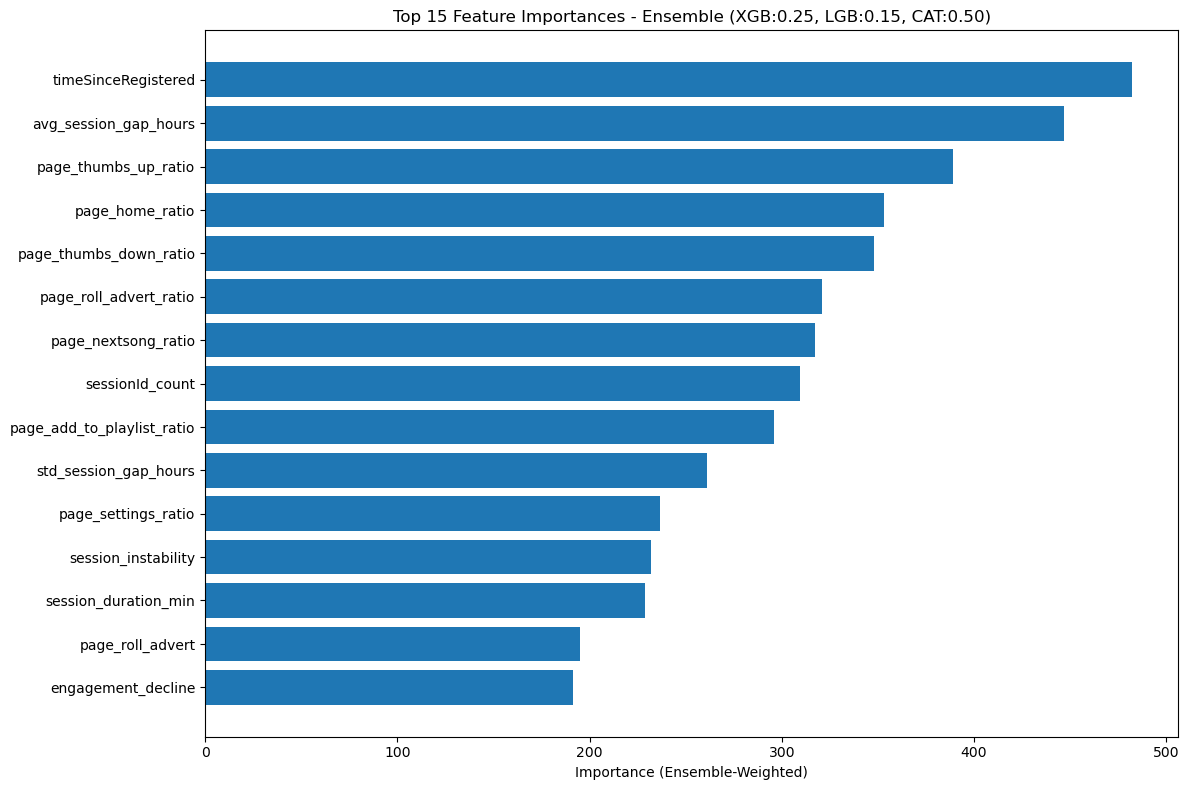

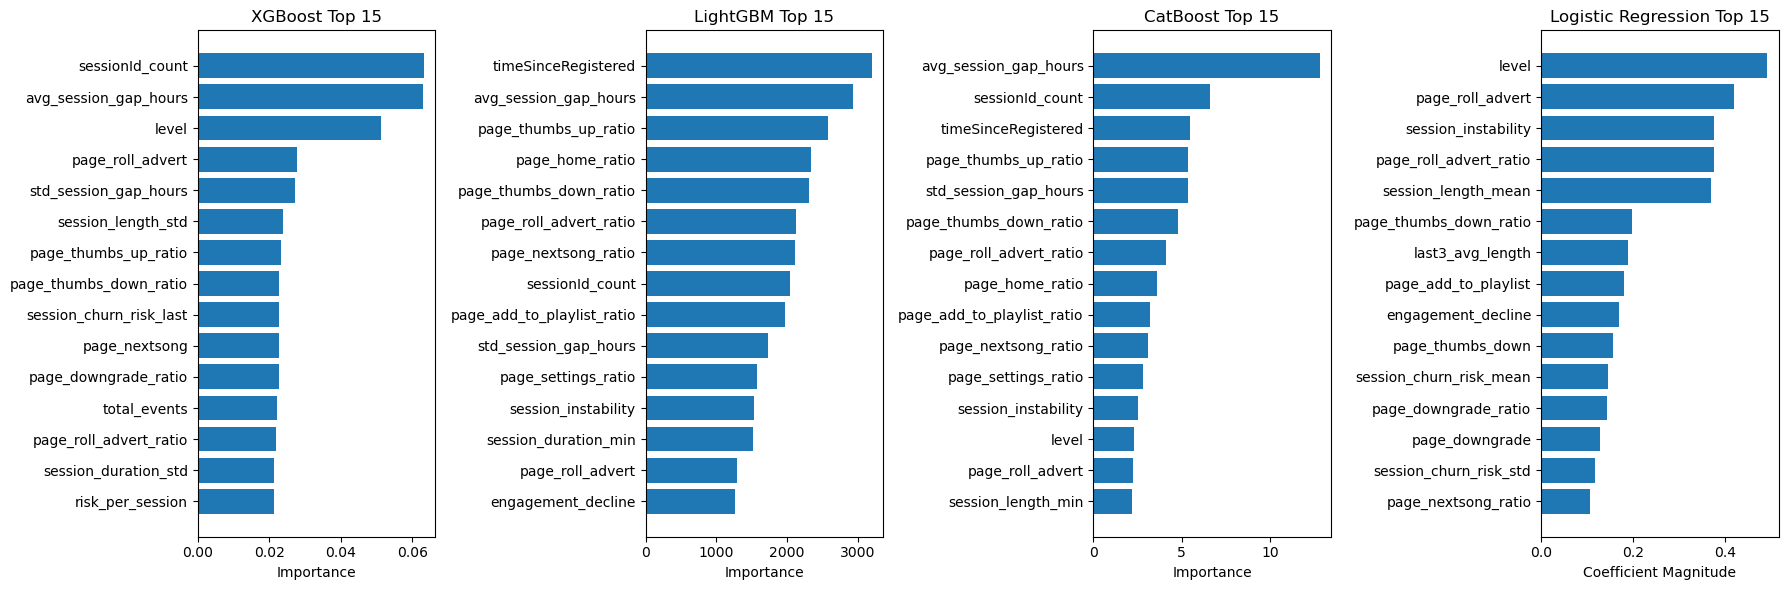

In [145]:
feature_names = X_user.columns.tolist()

xgb_importance = final_xgb.named_steps['xgbclassifier'].feature_importances_
lgb_importance = final_lgb.named_steps['lgbmclassifier'].feature_importances_
cat_importance = final_cat.named_steps['catboostclassifier'].feature_importances_
logreg_importance = final_logreg.named_steps['logisticregression'].coef_[0]

ensemble_importance = (
    best_config['xgb'] * xgb_importance +
    best_config['lgb'] * lgb_importance +
    best_config['cat'] * cat_importance +
    best_config['logreg'] * logreg_importance
)

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'xgb_importance': xgb_importance,
    'lgb_importance': lgb_importance,
    'cat_importance': cat_importance,
    'logreg_importance': logreg_importance,
    'ensemble_importance': ensemble_importance
}).sort_values('ensemble_importance', ascending=False)

print("\n" + "="*70)
print("TOP 20 FEATURES (ENSEMBLE-WEIGHTED)")
print("="*70)
print(feature_importance.head(20)[['feature', 'ensemble_importance']].to_string(index=False))

# Plot top 15 features
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['ensemble_importance'].values)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Importance (Ensemble-Weighted)')
plt.title(f'Top 15 Feature Importances - Ensemble (XGB:{best_config["xgb"]:.2f}, LGB:{best_config["lgb"]:.2f}, CAT:{best_config["cat"]:.2f})')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Individual model comparisons
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

# XGBoost
top_xgb = feature_importance.nlargest(15, 'xgb_importance')
axes[0].barh(range(len(top_xgb)), top_xgb['xgb_importance'].values)
axes[0].set_yticks(range(len(top_xgb)))
axes[0].set_yticklabels(top_xgb['feature'].values)
axes[0].set_xlabel('Importance')
axes[0].set_title('XGBoost Top 15')
axes[0].invert_yaxis()

# LightGBM
top_lgb = feature_importance.nlargest(15, 'lgb_importance')
axes[1].barh(range(len(top_lgb)), top_lgb['lgb_importance'].values)
axes[1].set_yticks(range(len(top_lgb)))
axes[1].set_yticklabels(top_lgb['feature'].values)
axes[1].set_xlabel('Importance')
axes[1].set_title('LightGBM Top 15')
axes[1].invert_yaxis()

# CatBoost
top_cat = feature_importance.nlargest(15, 'cat_importance')
axes[2].barh(range(len(top_cat)), top_cat['cat_importance'].values)
axes[2].set_yticks(range(len(top_cat)))
axes[2].set_yticklabels(top_cat['feature'].values)
axes[2].set_xlabel('Importance')
axes[2].set_title('CatBoost Top 15')
axes[2].invert_yaxis()

# Logistic Regression
top_logreg = feature_importance.nlargest(15, 'logreg_importance')
axes[3].barh(range(len(top_logreg)), top_logreg['logreg_importance'].values)
axes[3].set_yticks(range(len(top_logreg)))
axes[3].set_yticklabels(top_logreg['feature'].values)
axes[3].set_xlabel('Coefficient Magnitude')
axes[3].set_title('Logistic Regression Top 15')
axes[3].invert_yaxis()

plt.tight_layout()
plt.show()


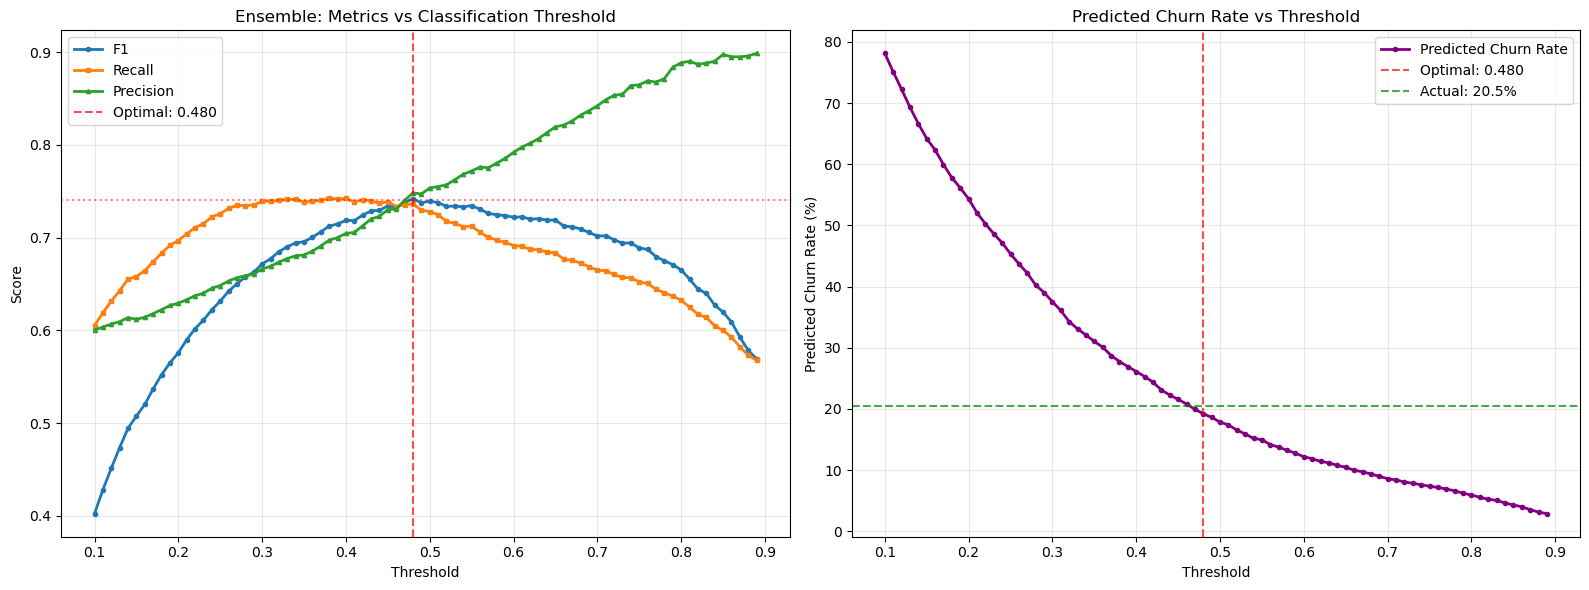

Optimal threshold: 0.480
Best F1-score: 0.7421
Recall at optimal: 0.7365
Precision at optimal: 0.7483
Predicted churn rate: 19.21%
Actual churn rate: 20.49%
 threshold       f1   recall  precision  pred_churn_rate
      0.48 0.742057 0.736507   0.748275         0.192084
      0.50 0.739339 0.728137   0.753558         0.178405
      0.47 0.737875 0.735504   0.740365         0.199360
      0.51 0.737839 0.724812   0.755114         0.173749
      0.49 0.737630 0.729631   0.747110         0.185972
      0.55 0.734563 0.712312   0.771885         0.149593
      0.45 0.734345 0.738837   0.730252         0.215367
      0.53 0.734019 0.715388   0.762533         0.158906
      0.52 0.733733 0.717614   0.756929         0.165308
      0.54 0.733269 0.711924   0.768385         0.151630
XGBoost: threshold=0.550, F1=0.7317
LightGBM: threshold=0.530, F1=0.7302
CatBoost: threshold=0.520, F1=0.7400
Logistic Regression: threshold=0.340, F1=0.6736
Ensemble: threshold=0.480, F1=0.7421


In [146]:
# Get ensemble probabilities on validation set
ens_val_proba = (best_config['xgb'] * xgb_proba + 
                 best_config['lgb'] * lgb_proba + 
                 best_config['cat'] * cat_proba + 
                 best_config['logreg'] * logreg_proba)

# Test thresholds
thresholds = np.arange(0.1, 0.9, 0.01)  # Fine-grained for better visualization
threshold_results = []

for threshold in thresholds:
    y_pred_thresh = (ens_val_proba >= threshold).astype(int)
    
    f1 = f1_score(y_val, y_pred_thresh, average='macro')
    recall = recall_score(y_val, y_pred_thresh, average='macro')
    precision = precision_score(y_val, y_pred_thresh, average='macro')
    
    # Additional metrics
    pred_churn_rate = y_pred_thresh.mean()
    
    threshold_results.append({
        'threshold': threshold,
        'f1': f1,
        'recall': recall,
        'precision': precision,
        'pred_churn_rate': pred_churn_rate
    })

threshold_df = pd.DataFrame(threshold_results)

# Plot main metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: F1, Recall, Precision
axes[0].plot(threshold_df['threshold'], threshold_df['f1'], 'o-', label='F1', linewidth=2, markersize=3)
axes[0].plot(threshold_df['threshold'], threshold_df['recall'], 's-', label='Recall', linewidth=2, markersize=3)
axes[0].plot(threshold_df['threshold'], threshold_df['precision'], '^-', label='Precision', linewidth=2, markersize=3)
axes[0].axvline(best_config['threshold'], color='red', linestyle='--', alpha=0.7, label=f'Optimal: {best_config["threshold"]:.3f}')
axes[0].axhline(best_f1, color='red', linestyle=':', alpha=0.5)
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Ensemble: Metrics vs Classification Threshold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right plot: Predicted churn rate
axes[1].plot(threshold_df['threshold'], threshold_df['pred_churn_rate'] * 100, 'o-', 
             color='purple', linewidth=2, markersize=3, label='Predicted Churn Rate')
axes[1].axvline(best_config['threshold'], color='red', linestyle='--', alpha=0.7, 
                label=f'Optimal: {best_config["threshold"]:.3f}')
axes[1].axhline(y_val.mean() * 100, color='green', linestyle='--', alpha=0.7, 
                label=f'Actual: {y_val.mean()*100:.1f}%')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Predicted Churn Rate (%)')
axes[1].set_title('Predicted Churn Rate vs Threshold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Find optimal and show top results
optimal_row = threshold_df.loc[threshold_df['f1'].idxmax()]

print(f"Optimal threshold: {optimal_row['threshold']:.3f}")
print(f"Best F1-score: {optimal_row['f1']:.4f}")
print(f"Recall at optimal: {optimal_row['recall']:.4f}")
print(f"Precision at optimal: {optimal_row['precision']:.4f}")
print(f"Predicted churn rate: {optimal_row['pred_churn_rate']*100:.2f}%")
print(f"Actual churn rate: {y_val.mean()*100:.2f}%")


print(threshold_df.nlargest(10, 'f1')[['threshold', 'f1', 'recall', 'precision', 'pred_churn_rate']].to_string(index=False))

# Compare with individual models

# XGBoost
xgb_threshold_results = []
for threshold in np.arange(0.1, 0.9, 0.01):
    y_pred = (xgb_proba >= threshold).astype(int)
    f1 = f1_score(y_val, y_pred, average='macro')
    xgb_threshold_results.append({'threshold': threshold, 'f1': f1})
xgb_threshold_df = pd.DataFrame(xgb_threshold_results)
xgb_best = xgb_threshold_df.loc[xgb_threshold_df['f1'].idxmax()]
print(f"XGBoost: threshold={xgb_best['threshold']:.3f}, F1={xgb_best['f1']:.4f}")

# LightGBM
lgb_threshold_results = []
for threshold in np.arange(0.1, 0.9, 0.01):
    y_pred = (lgb_proba >= threshold).astype(int)
    f1 = f1_score(y_val, y_pred, average='macro')
    lgb_threshold_results.append({'threshold': threshold, 'f1': f1})
lgb_threshold_df = pd.DataFrame(lgb_threshold_results)
lgb_best = lgb_threshold_df.loc[lgb_threshold_df['f1'].idxmax()]
print(f"LightGBM: threshold={lgb_best['threshold']:.3f}, F1={lgb_best['f1']:.4f}")

# CatBoost
cat_threshold_results = []
for threshold in np.arange(0.1, 0.9, 0.01):
    y_pred = (cat_proba >= threshold).astype(int)
    f1 = f1_score(y_val, y_pred, average='macro')
    cat_threshold_results.append({'threshold': threshold, 'f1': f1})
cat_threshold_df = pd.DataFrame(cat_threshold_results)
cat_best = cat_threshold_df.loc[cat_threshold_df['f1'].idxmax()]
print(f"CatBoost: threshold={cat_best['threshold']:.3f}, F1={cat_best['f1']:.4f}")

# Logistic Regression
logreg_threshold_results = []
for threshold in np.arange(0.1, 0.9, 0.01):
    y_pred = (logreg_proba >= threshold).astype(int)
    f1 = f1_score(y_val, y_pred, average='macro')
    logreg_threshold_results.append({'threshold': threshold, 'f1': f1})
logreg_threshold_df = pd.DataFrame(logreg_threshold_results)
logreg_best = logreg_threshold_df.loc[logreg_threshold_df['f1'].idxmax()]
print(f"Logistic Regression: threshold={logreg_best['threshold']:.3f}, F1={logreg_best['f1']:.4f}")

print(f"Ensemble: threshold={optimal_row['threshold']:.3f}, F1={optimal_row['f1']:.4f}")

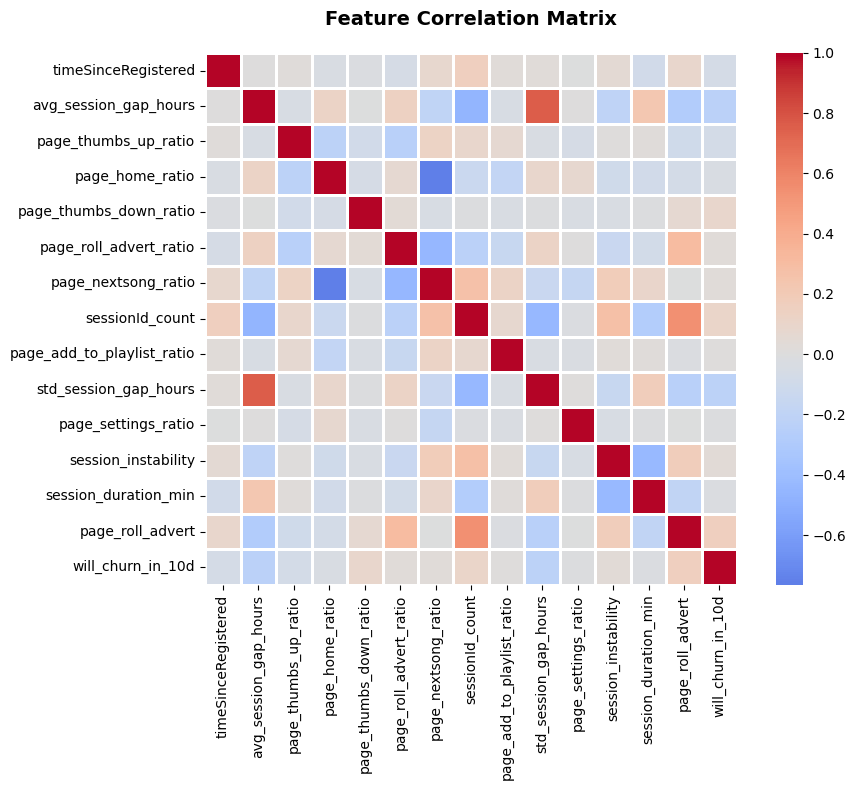


Correlation with Churn Target:
page_roll_advert              0.162531
sessionId_count               0.104597
page_thumbs_down_ratio        0.092291
session_instability           0.037382
page_roll_advert_ratio        0.028851
page_nextsong_ratio           0.026217
page_add_to_playlist_ratio    0.012024
page_settings_ratio          -0.006888
session_duration_min         -0.016096
page_home_ratio              -0.033496
timeSinceRegistered          -0.064857
page_thumbs_up_ratio         -0.070442
std_session_gap_hours        -0.225187
avg_session_gap_hours        -0.228363
Name: will_churn_in_10d, dtype: float64


In [154]:
# === CORRELATION ANALYSIS ===

# Feature correlations with churn
correlation_features = ['timeSinceRegistered', 'avg_session_gap_hours', 'page_thumbs_up_ratio',
                        'page_home_ratio', 'page_thumbs_down_ratio', 'page_roll_advert_ratio',
                        'page_nextsong_ratio', 'sessionId_count', 'page_add_to_playlist_ratio',
                        'std_session_gap_hours', 'page_settings_ratio', 'session_instability',
                        'session_duration_min', 'page_roll_advert', 'will_churn_in_10d']

correlation_matrix = train_full[correlation_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Correlation with target
target_corr = correlation_matrix['will_churn_in_10d'].drop('will_churn_in_10d').sort_values(ascending=False)
print("\nCorrelation with Churn Target:")
print(target_corr)